# Machine Learning for Sintering of Copper Nanoparticles: Predictive Modelling via CNN and PINN
**Course Project | Computational Materials Science & ML**

**Targets:** Neck Radius, Neck Ratio, Shrinkage Ratio, Density, MSD  
**Models:** 1D CNN, Physics-Informed Neural Network (PINN)  
**Data Source:** LAMMPS Molecular Dynamics Simulations of Cu Nanoparticle Sintering

---
> **Usage:** Upload `sintering_dataset_updated.csv` to the Colab session or mount your Google Drive.

## 0. Environment Setup & Imports

In [ ]:
# Install dependencies (run once)
!pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn scipy joblib tqdm -q
#!pip install tensorflow

In [ ]:
import os, warnings, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.10.0+cpu


## 1. Data Loading

In [ ]:
# ---------------------------------------------------------------
# Option A: Upload manually to Colab
# from google.colab import files
# uploaded = files.upload()  # Upload sintering_dataset_updated.csv
# DATA_PATH = list(uploaded.keys())[0]

# Option B: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/Othercomputers/MyLaptop/TERM2/CDS524_ML4B/Assign_Grp/LAMMPS_TRAJ_FILEs/' # Update your input file path

# Option C: Local path
#DATA_PATH = 'sintering_dataset_updated.csv'

# ---------------------------------------------------------------
df = pd.read_csv('sintering_dataset_updated.csv', index_col=0)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(5)

Mounted at /content/drive
Dataset shape: (7200, 21)
Columns: ['time', 'Dt', 'neck_radius', 'neck_ratio', 'shrinkage', 'density', 'msd', 'gyration_radius', 'avg_coordination', 'fcc_fraction', 'SAreaVol_ratio', 'potential_energy', 'sim_id', 'r1', 'r2', 'T', 'particle_type', 'size_ratio', 'time_norm', 'r_min', 'r_max']


,time,Dt,neck_radius,neck_ratio,shrinkage,density,msd,gyration_radius,avg_coordination,fcc_fraction,...,potential_energy,sim_id,r1,r2,T,particle_type,size_ratio,time_norm,r_min,r_max
0,1.0,68.459297,0.0,0.0,0.000000,7.101322,0.0993,42.609890,12.010643,0.758248,...,-3.402275,R9_R9_T300,32.535,32.535,300.0,same,1.0,0.005,32.535,32.535
1,2.0,68.445919,0.0,0.0,0.000195,7.145627,0.0785,42.521936,12.160213,0.711257,...,-3.402671,R9_R9_T300,32.535,32.535,300.0,same,1.0,0.010,32.535,32.535
2,3.0,68.426511,0.0,0.0,0.000479,7.175674,0.0816,42.525126,12.135489,0.719443,...,-3.404200,R9_R9_T300,32.535,32.535,300.0,same,1.0,0.015,32.535,32.535
3,4.0,68.402003,0.0,0.0,0.000837,7.128040,0.0979,42.565883,12.047401,0.744986,...,-3.401642,R9_R9_T300,32.535,32.535,300.0,same,1.0,0.020,32.535,32.535
4,5.0,68.369259,0.0,0.0,0.001315,7.217585,0.1080,42.465140,12.207777,0.697094,...,-3.403272,R9_R9_T300,32.535,32.535,300.0,same,1.0,0.025,32.535,32.535


## 2. Dataset Description & Preprocessing

In [ ]:
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f"Total samples  : {len(df):,}")
print(f"Unique sims    : {df['sim_id'].nunique()}")
print(f"Temperatures   : {sorted(df['T'].unique())} K")
print(f"Particle types : {df['particle_type'].value_counts().to_dict()}")
print(f"Missing values : {df.isnull().sum().sum()}")
print()
TARGETS = ['neck_radius', 'neck_ratio', 'shrinkage', 'density', 'msd']
print('Target Statistics:')
display(df[TARGETS].describe().round(4))

DATASET OVERVIEW
Total samples  : 7,200
Unique sims    : 36
Temperatures   : [np.float64(300.0), np.float64(500.0), np.float64(700.0), np.float64(900.0)] K
Particle types : {'diff': 4000, 'same': 3200}
Missing values : 0

Target Statistics:


,neck_radius,neck_ratio,shrinkage,density,msd
count,7200.0000,7200.0000,7200.0000,7200.0000,7200.0000
mean,16.8282,0.6959,0.1395,8.3016,18.8057
std,6.9771,0.2977,0.1310,0.7968,20.8819
min,0.0000,0.0000,-0.0022,6.8046,0.0310
25%,12.4246,0.5418,0.0369,7.5950,4.5110
50%,16.6492,0.6795,0.1175,8.1015,16.7476
75%,21.3558,0.8381,0.1683,8.8980,22.2838
max,40.1187,1.5540,0.7013,10.1089,160.7345


In [ ]:
# ============================================================
# PREPROCESSING
# ============================================================

# 1. Encode categorical feature
df['particle_type_enc'] = (df['particle_type'] == 'diff').astype(int)

# 2. Feature selection — physics-motivated
# Remove: sim_id (identifier), particle_type (encoded), time (use time_norm),
#         neck_ratio/neck_radius are co-targets, r1/r2 replaced by r_min/r_max
FEATURES = [
    'time_norm',          # Normalized simulation time (dimensionless)
    'Dt',                 # Centroid-to-centroid distance (Å) — tracks sintering progress
    'gyration_radius',    # Radius of gyration — shape/compactness indicator
    'avg_coordination',   # Average coordination number — structural order
    'fcc_fraction',       # Fraction of FCC atoms — crystallinity indicator
    'SAreaVol_ratio',     # Surface-area-to-volume ratio — surface energy driver
    'potential_energy',   # Potential energy — thermodynamic state
    'r_min',              # Smaller particle radius (Å)
    'r_max',              # Larger particle radius (Å)
    'T',                  # Temperature (K) — key sintering driver
    'size_ratio'#,         # r2/r1 — asymmetry factor
    #'particle_type_enc'   # Binary: 0=equal-sized, 1=unequal
]
TARGETS = ['neck_radius', 'neck_ratio', 'shrinkage', 'density', 'msd']

print(f'Features ({len(FEATURES)}):', FEATURES)
print(f'Targets  ({len(TARGETS)}):', TARGETS)

# 3. Check feature correlation with targets
corr_with_targets = df[FEATURES + TARGETS].corr()[TARGETS].loc[FEATURES]
print('\nTop correlations with targets:')
display(corr_with_targets.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))


Features (11): ['time_norm', 'Dt', 'gyration_radius', 'avg_coordination', 'fcc_fraction', 'SAreaVol_ratio', 'potential_energy', 'r_min', 'r_max', 'T', 'size_ratio']
Targets  (5): ['neck_radius', 'neck_ratio', 'shrinkage', 'density', 'msd']

Top correlations with targets:


,neck_radius,neck_ratio,shrinkage,density,msd
time_norm,0.427615,0.352343,0.133947,0.098453,0.231475
Dt,0.361191,-0.544879,-0.426756,-0.908568,-0.215870
gyration_radius,0.358793,-0.602052,-0.579875,-0.849385,-0.318899
avg_coordination,0.480467,-0.376947,-0.673697,-0.667190,-0.358487
fcc_fraction,-0.044234,-0.726742,-0.711059,-0.483884,-0.570542
SAreaVol_ratio,-0.323023,0.637530,0.811717,0.771976,0.521840
potential_energy,-0.045753,0.749778,0.798811,0.569012,0.659383
r_min,0.414093,-0.382133,-0.211949,-0.868614,-0.021839
r_max,0.305149,-0.605219,-0.753297,-0.624650,-0.481453
T,0.444928,0.430190,0.142067,-0.067262,0.311525


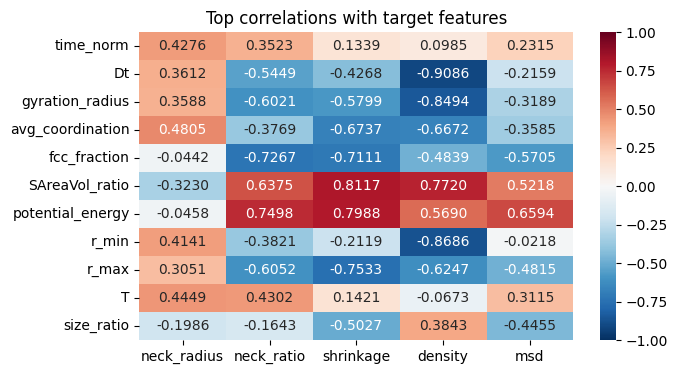

In [ ]:
# Compute the correlation matrix
corr_matrix = df[FEATURES + TARGETS].corr()[TARGETS].loc[FEATURES] #df.select_dtypes([np.number]).corr() # select only numeric columns

# Plot the heatmap using seaborn
plt.figure(figsize=(7, 4)) # Adjust figure size for better readability
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".4f", vmin=-1, vmax=1, cbar=True, square=False)
# annot=True displays the correlation coefficients in each cell
# cmap='RdBu_r' uses a divergent colormap centered at zero
# vmin and vmax set the color bar range from -1 to 1

# 4. Add title and display the plot
plt.title('Top correlations with target features')
plt.savefig('fig1_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Exploratory Data Analysis (EDA)

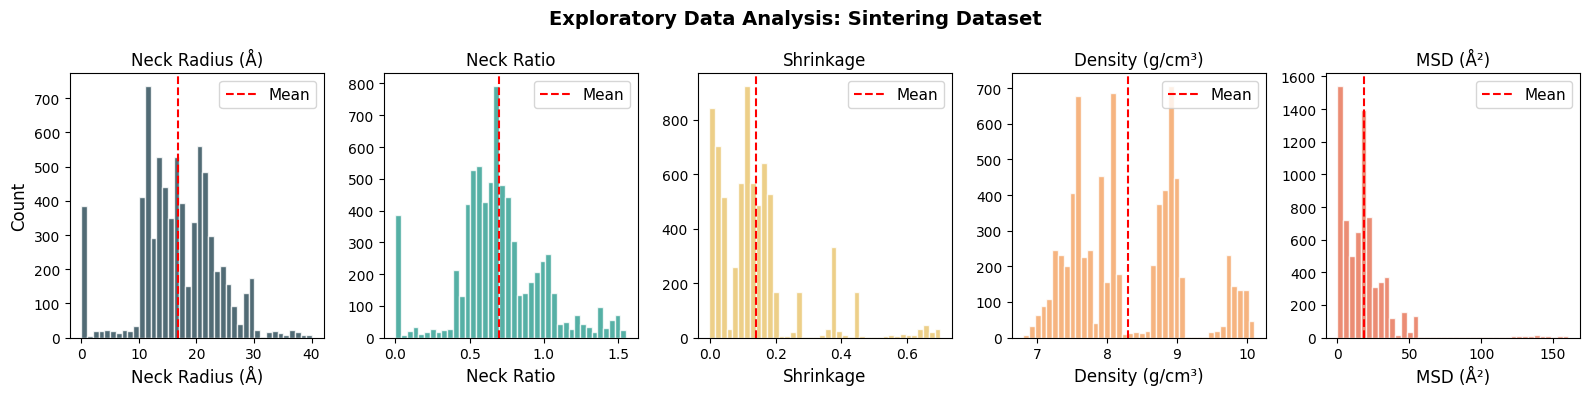

In [ ]:
# --- 3.1 Target Distributions ---
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Exploratory Data Analysis: Sintering Dataset', fontsize=14, fontweight='bold')
colors = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51']
labels = ['Neck Radius (Å)', 'Neck Ratio', 'Shrinkage', 'Density (g/cm³)', 'MSD (Å²)']
for ax, t, c, lbl in zip(axes, TARGETS, colors, labels):
    ax.hist(df[t], bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lbl, fontsize=12)
    ax.set_xlabel(lbl,fontsize=12)
    ax.axvline(df[t].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    ax.legend(fontsize=11)
axes[0].set_ylabel('Count',fontsize=12)
plt.tight_layout()
plt.savefig('fig2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

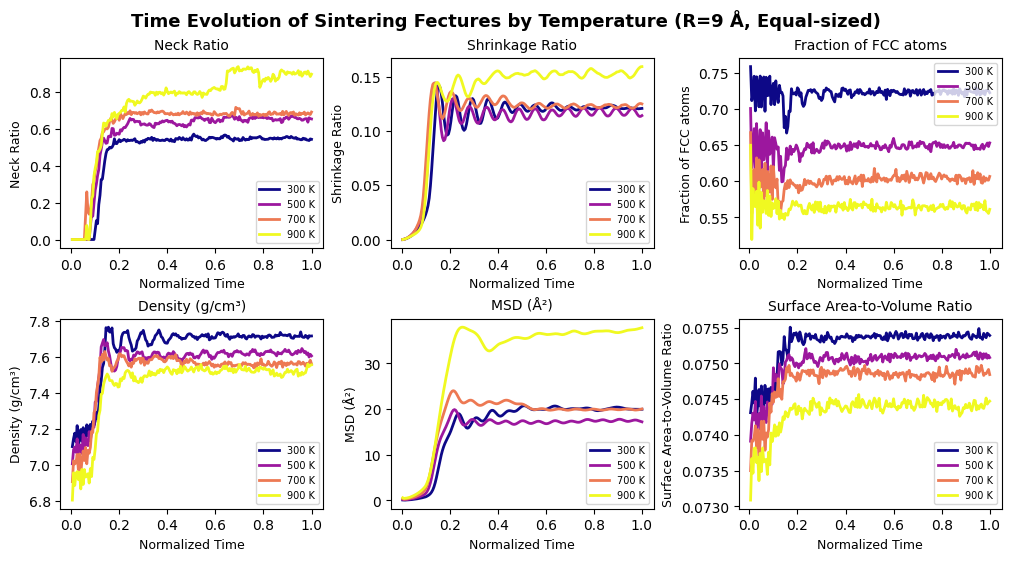

In [ ]:
# --- 3.2 Time Evolution by Temperature ---
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5),constrained_layout=True)
fig.suptitle('Time Evolution of Sintering Fectures by Temperature (R=9 Å, Equal-sized)', fontsize=13, fontweight='bold')
temps = [300, 500, 700, 900]
cmap = plt.cm.plasma
tcolors = [cmap(i/3) for i in range(4)]
plot_cfg = [
    ('neck_ratio', 'Neck Ratio'), ('shrinkage', 'Shrinkage Ratio'),
    ('fcc_fraction', 'Fraction of FCC atoms'), ('density', 'Density (g/cm³)'),
    ('msd', 'MSD (Å²)'), ('SAreaVol_ratio', 'Surface Area-to-Volume Ratio')
]
for ax, (tgt, ylabel) in zip(axes.flatten(), plot_cfg):
    for T, c in zip(temps, tcolors):
        sim = f'R9_R9_T{int(T)}'
        sub = df[df['sim_id']==sim]
        if len(sub): ax.plot(sub['time_norm'], sub[tgt], color=c, lw=2, label=f'{T} K')
    ax.set_xlabel('Normalized Time', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel, fontsize=10)
    ax.legend(fontsize=7)
    #ax.grid(alpha=0.3)
#axes[1,2].set_yticklabels([7.25,'7.30',7.35,'7.40',7.45,'7.50',7.55])
#plt.tight_layout()
plt.savefig('fig3_time_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

Same plot as the above but puts inset plots in each subplot

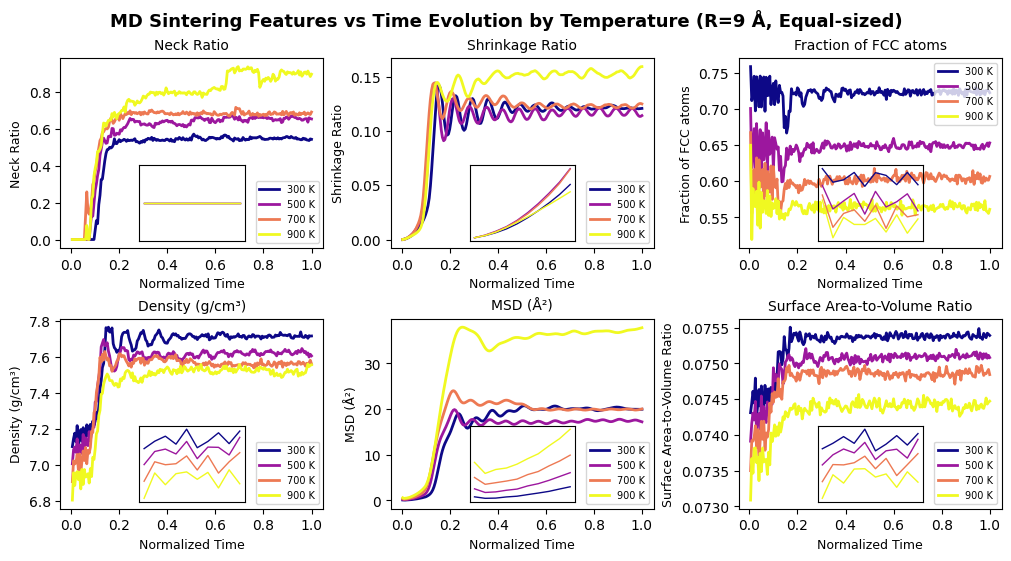

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(2, 3, figsize=(10, 5.5), constrained_layout=True)
fig.suptitle('MD Sintering Features vs Time Evolution by Temperature (R=9 Å, Equal-sized)', fontsize=13, fontweight='bold')

temps = [300, 500, 700, 900]
cmap = plt.cm.plasma
tcolors = [cmap(i/3) for i in range(4)]

plot_cfg = [
    ('neck_ratio', 'Neck Ratio'),
    ('shrinkage', 'Shrinkage Ratio'),
    ('fcc_fraction', 'Fraction of FCC atoms'),
    ('density', 'Density (g/cm³)'),
    ('msd', 'MSD (Å²)'),
    ('SAreaVol_ratio', 'Surface Area-to-Volume Ratio')
]

for ax, (tgt, ylabel) in zip(axes.flatten(), plot_cfg):
    for T, c in zip(temps, tcolors):
        sim = f'R9_R9_T{int(T)}'
        sub = df[df['sim_id']==sim]
        if len(sub):
            ax.plot(sub['time_norm'], sub[tgt], color=c, lw=2, label=f'{T} K')
    ax.set_xlabel('Normalized Time', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel, fontsize=10)
    ax.legend(fontsize=7)

    # Create an inset plot
    ax_inset = inset_axes(ax, width="40%", height="40%", loc='lower center')
    for T, c in zip(temps, tcolors):
        sim = f'R9_R9_T{int(T)}'
        sub = df[df['sim_id']==sim]
        if len(sub):
            ax_inset.plot(sub['time_norm'][:10], sub[tgt][:10], color=c, lw=1)
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_facecolor('none')
    ax_inset.patch.set_alpha(0)

#plt.savefig('fig3_time_evolution.png', dpi=150, bbox_inches='tight')
plt.show()


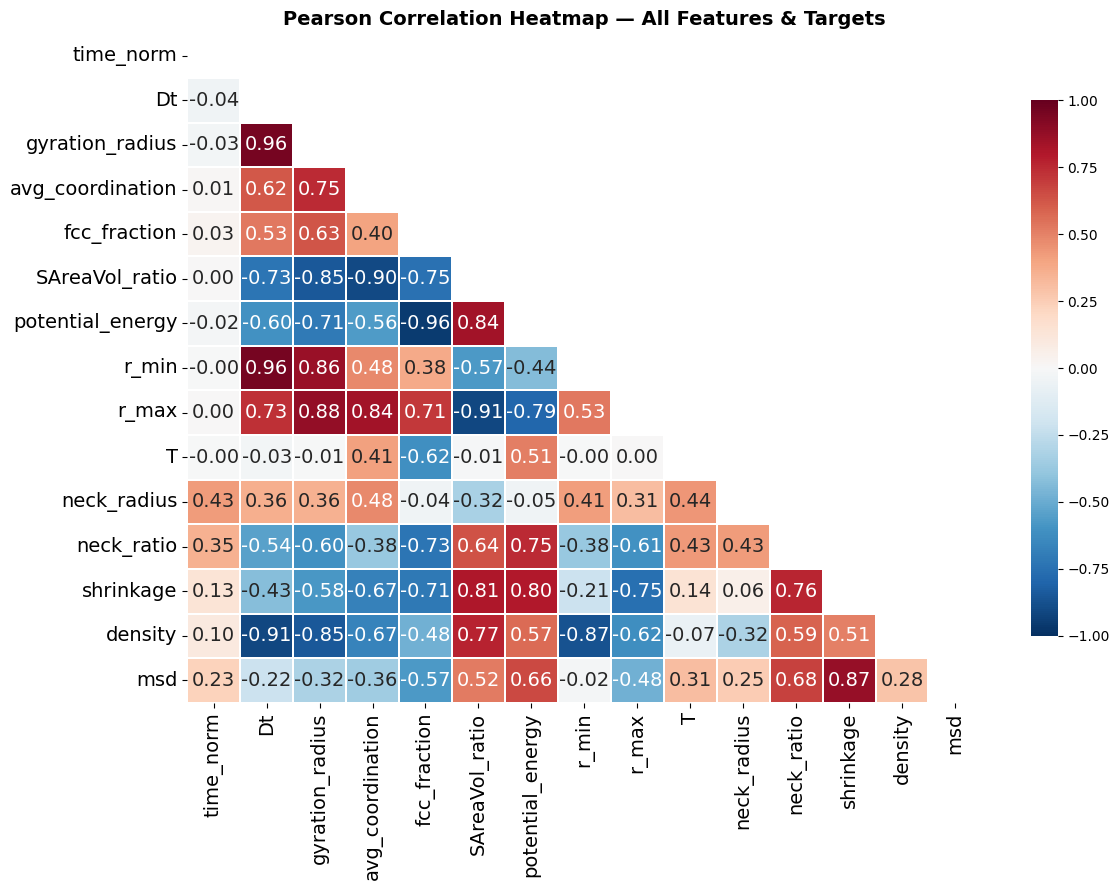

In [ ]:
# --- 3.3 Correlation Heatmap ---
num_cols = FEATURES[:-1] + TARGETS  # exclude particle_type_enc binary
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.3, ax=ax, annot_kws={'size':14}, vmin=-1, vmax=1,
            cbar_kws={'shrink':0.8})
ax.set_title('Pearson Correlation Heatmap — All Features & Targets', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.savefig('fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

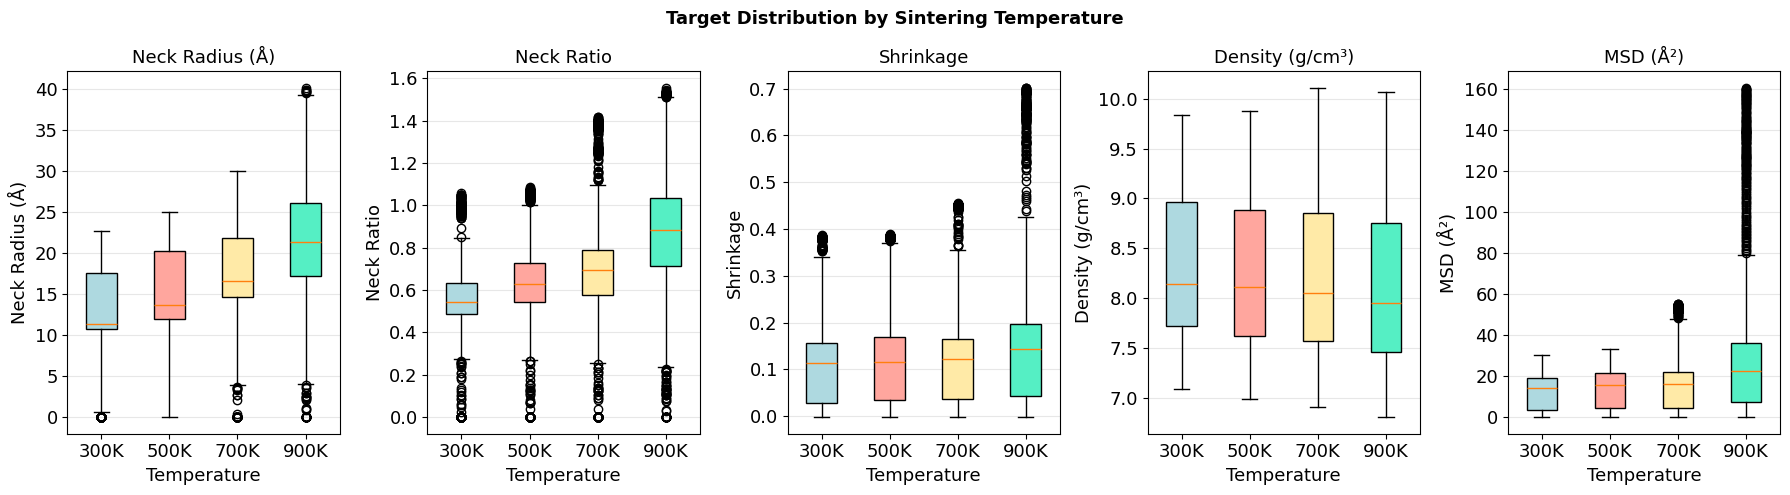

In [ ]:
# --- 3.4 Boxplots by Temperature ---
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Target Distribution by Sintering Temperature', fontsize=13, fontweight='bold')
ylabels = ['Neck Radius (Å)', 'Neck Ratio', 'Shrinkage', 'Density (g/cm³)', 'MSD (Å²)']
for ax, t, yl in zip(axes, TARGETS, ylabels):
    data_by_T = [df[df['T']==T][t].values for T in [300,500,700,900]]
    bp = ax.boxplot(data_by_T, patch_artist=True, labels=['300K','500K','700K','900K'])
    colors_bp = ['#aed9e0','#ffa69e','#ffeaa7','#55efc4']
    for patch, c in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(c)
    ax.set_title(yl, fontsize=13)
    ax.set_xlabel('Temperature', fontsize=13); ax.set_ylabel(yl, fontsize=13)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.tight_layout()
plt.savefig('fig5_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Handle Outliers

In [ ]:
for column in ['neck_radius', 'neck_ratio', 'shrinkage', 'density', 'msd']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    #df = df[(df[column] > lower_bound) & (df[column] < upper_bound)]
print(df['neck_radius'].shape,df['neck_ratio'].shape,df['T'].shape)   # Check that target and input features have same lenght

(7200,) (7200,) (7200,)


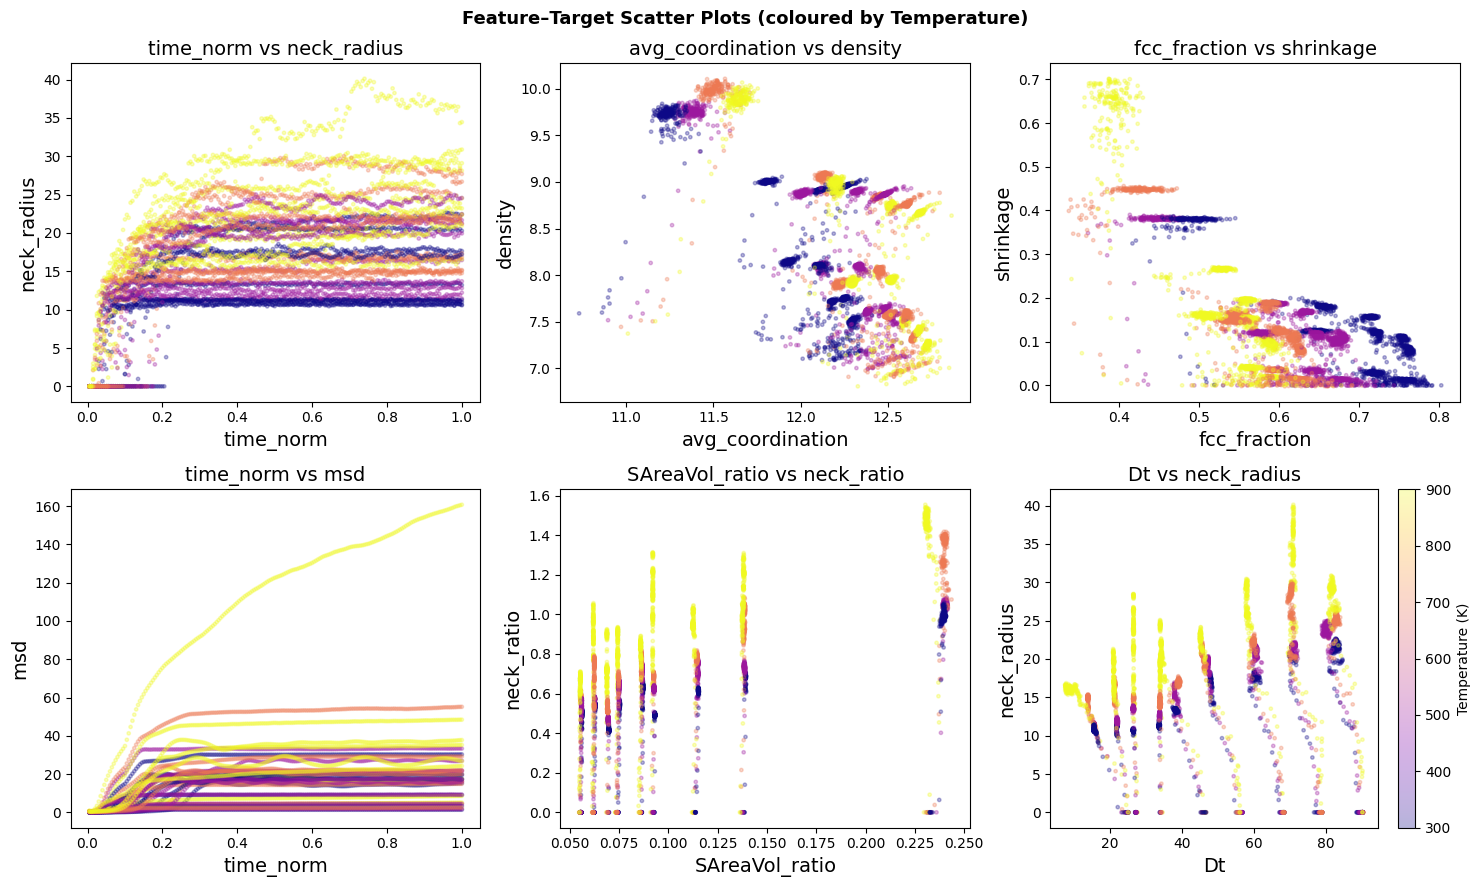

In [ ]:
# --- 3.5 Scatter: Key Feature Pairs ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Feature–Target Scatter Plots (coloured by Temperature)', fontsize=13, fontweight='bold')
pairs = [
    ('time_norm','neck_radius'), ('avg_coordination','density'),
    ('fcc_fraction','shrinkage'), ('time_norm','msd'),
    ('SAreaVol_ratio','neck_ratio'), ('Dt','neck_radius')
]
for ax, (fx, ty) in zip(axes.flatten(), pairs):
    sc = ax.scatter(df[fx], df[ty], c=df['T'], cmap='plasma', alpha=0.3, s=6)
    ax.set_xlabel(fx, fontsize=14); ax.set_ylabel(ty, fontsize=14)
    ax.set_title(f'{fx} vs {ty}', fontsize=14)
plt.colorbar(sc, ax=axes.flatten()[-1], label='Temperature (K)')
plt.tight_layout()
plt.savefig('fig6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Do Principal Component Analysis (PCA)

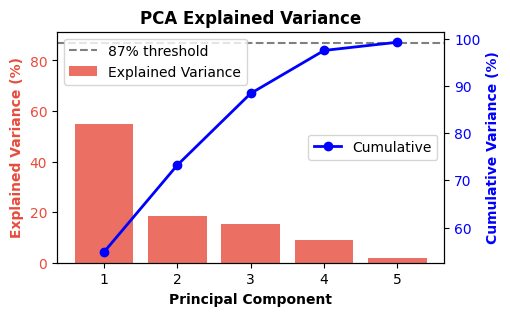

Variance explained by 3 PCs: 88.4%


In [ ]:
PALETTE = ['#2E86C1', '#F39C12', '#1ABC9C', '#E74C3C', '#8E44AD']
input_cols = ['time_norm', 'Dt', 'gyration_radius', 'avg_coordination',
              'fcc_fraction', 'SAreaVol_ratio', 'potential_energy',
              'r_min', 'r_max', 'T', 'size_ratio'
              ]
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df[input_cols])
pca = PCA(n_components=5)
pca_coords = pca.fit_transform(X_pca)

fig, axes = plt.subplots( figsize=(5, 3))
# Explained variance
axes.bar(range(1, 6), pca.explained_variance_ratio_ * 100, color=PALETTE[3], alpha=0.8, label='Explained Variance')
axes.axhline(87, ls='--', color='gray', label='87% threshold')
axes.legend(loc='upper left')
axes.tick_params(axis='y', labelcolor=PALETTE[3])
axes.set_ylabel('Explained Variance (%)',color=PALETTE[3],fontweight='bold'),
axes.set_title('PCA Explained Variance',fontweight='bold')
axes.set_xlabel('Principal Component',fontweight='bold')
ax2 = axes.twinx()
ax2.plot(range(1, 6), np.cumsum(pca.explained_variance_ratio_) * 100, 'o-', color='blue', lw=2, label='Cumulative')
ax2.set_ylabel('Cumulative Variance (%)',color='blue',fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.legend(loc='center right')

#plt.suptitle('Principal Component Analysis of Input Feature Space', fontsize=13, fontweight='bold')
plt.savefig('fig7_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Variance explained by 3 PCs: {np.sum(pca.explained_variance_ratio_[:3])*100:.1f}%')

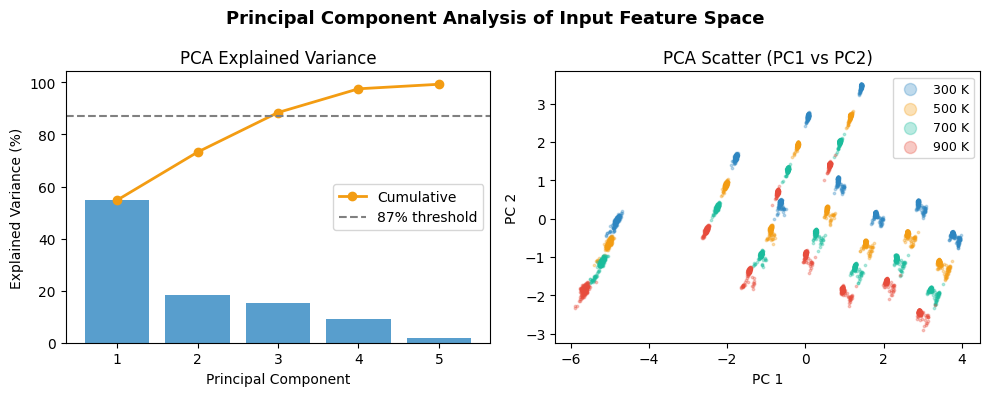

Variance explained by 3 PCs: 88.4%


In [ ]:
# ── 4.5 PCA Analysis ────────────────────────────────────────────────────────
PALETTE = ['#2E86C1', '#F39C12', '#1ABC9C', '#E74C3C', '#8E44AD']
input_cols = ['time_norm', 'Dt', 'gyration_radius', 'avg_coordination',
              'fcc_fraction', 'SAreaVol_ratio', 'potential_energy',
              'r_min', 'r_max', 'T', 'size_ratio'
              ]
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df[input_cols])
pca = PCA(n_components=5)
pca_coords = pca.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Explained variance
axes[0].bar(range(1, 6), pca.explained_variance_ratio_ * 100, color=PALETTE[0], alpha=0.8)
axes[0].plot(range(1, 6), np.cumsum(pca.explained_variance_ratio_) * 100,
             'o-', color=PALETTE[1], lw=2, label='Cumulative')
axes[0].axhline(87, ls='--', color='gray', label='87% threshold')
axes[0].set(xlabel='Principal Component', ylabel='Explained Variance (%)',
             title='PCA Explained Variance')
axes[0].legend()

# PC1 vs PC2, coloured by temperature
scatter_colors = [PALETTE[temps.index(int(t)) % len(PALETTE)] for t in df['T']]
for j, Tp in enumerate(temps):
    mask = df['T'] == Tp
    axes[1].scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                    c=PALETTE[j], alpha=0.3, s=3, label=f'{Tp} K')
axes[1].set(xlabel='PC 1', ylabel='PC 2', title='PCA Scatter (PC1 vs PC2)')
axes[1].legend(markerscale=5, fontsize=9)

plt.suptitle('Principal Component Analysis of Input Feature Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Variance explained by 3 PCs: {np.sum(pca.explained_variance_ratio_[:3])*100:.1f}%')

## 4. Data Splitting & Scaling

In [ ]:
# Simulation-based 80:20 train/test split
# This ensures no temporal data leakage — test sims are completely unseen
sim_ids = df['sim_id'].unique()
np.random.shuffle(sim_ids)
n_train = int(0.8 * len(sim_ids))
train_sims = set(sim_ids[:n_train])
test_sims  = set(sim_ids[n_train:])

train_mask = df['sim_id'].isin(train_sims).values
test_mask  = df['sim_id'].isin(test_sims).values

X_all = df[FEATURES].values.astype(np.float32)
Y_all = df[TARGETS].values.astype(np.float32)

X_train_raw, X_test_raw = X_all[train_mask], X_all[test_mask]
Y_train_raw, Y_test_raw = Y_all[train_mask], Y_all[test_mask]

# StandardScaler — zero mean, unit variance
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train_raw)
X_test  = scaler_X.transform(X_test_raw)

scaler_Y = StandardScaler()
Y_train = scaler_Y.fit_transform(Y_train_raw)
Y_test  = scaler_Y.transform(Y_test_raw)

print(f'Train sims: {n_train}/{len(sim_ids)} | Train samples: {X_train.shape[0]:,}')
print(f'Test  sims: {len(test_sims)}/{len(sim_ids)} | Test samples:  {X_test.shape[0]:,}')

# Convert to tensors
X_tr_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
Y_tr_t = torch.tensor(Y_train, dtype=torch.float32).to(DEVICE)
X_te_t = torch.tensor(X_test,  dtype=torch.float32).to(DEVICE)
Y_te_t = torch.tensor(Y_test,  dtype=torch.float32).to(DEVICE)

Train sims: 28/36 | Train samples: 5,600
Test  sims: 8/36 | Test samples:  1,600


## 5. Model Architecture

In [ ]:
# ============================================================
# 5.1  1D-CNN MODEL
# Feature vector treated as a 1D signal of length F
# Conv1d captures local feature interactions
# ============================================================

class CNN1D(nn.Module):
    """1D Convolutional Neural Network for sintering property prediction.

    Architecture:
      Input (B, F) -> Reshape (B, 1, F)
      -> Conv1d(1→32, k=3) -> BN -> ReLU
      -> Conv1d(32→64, k=3) -> BN -> ReLU
      -> Conv1d(64→128, k=3) -> BN -> ReLU
      -> AdaptiveAvgPool1d(8)
      -> Flatten -> FC(1024→512→256→128→n_out)
    """
    def __init__(self, n_features: int, n_targets: int, dropout: float = 0.3):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(8)  # Output: (B, 128, 8)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 8, 512),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),      nn.ReLU(), nn.Dropout(dropout * 0.67),
            nn.Linear(256, 128),      nn.ReLU(),
            nn.Linear(128, n_targets)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.unsqueeze(1)            # (B, 1, F)
        x = self.conv_block(x)        # (B, 128, 8)
        x = x.flatten(1)              # (B, 1024)
        return self.fc(x)

cnn = CNN1D(len(FEATURES), len(TARGETS)).to(DEVICE)
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f'CNN total trainable parameters: {total_params:,}')
print(cnn)

CNN total trainable parameters: 721,157
CNN1D(
  (conv_block): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool1d(output_size=8)
  )
  (fc): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.201, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_fe

In [ ]:
# ============================================================
# 5.2  PHYSICS-INFORMED NEURAL NETWORK (PINN)
#
# The PINN adds a physics loss based on Kuczynski's neck
# growth model for surface diffusion:
#   d(neck_radius^7) / dt ∝ D_s * gamma * Omega / (k*T*r^3)
#
# Physics residual enforces: ∂(x^n)/∂t = C(T, r) for neck growth
# and Frenkel viscous flow for shrinkage.
# ============================================================

class PINN(nn.Module):
    """Physics-Informed Neural Network with Kuczynski neck-growth residual.

    Architecture: 5-layer fully-connected with Tanh activation (smooth, differentiable)
    Physics residual appended as auxiliary loss during training.
    """
    def __init__(self, n_features: int, n_targets: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),  nn.Tanh(),
            nn.Linear(128, 256),         nn.Tanh(),
            nn.Linear(256, 256),         nn.Tanh(),
            nn.Linear(256, 128),         nn.Tanh(),
            nn.Linear(128, n_targets)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


def pinn_physics_residual(x_batch, pred_batch, feature_names, target_names, scaler_X, scaler_Y):
    """
    Compute physics-based residual for neck growth:
    Kuczynski (surface diffusion): x^7 / r^4 = C1 * D_s0 * exp(-Q/kT) * t
    Frenkel shrinkage: dL/L0 = - (3*gamma / (4*eta*r)) * t

    We enforce: d(neck^7) / d(time_norm) ≈ alpha * r^4  (power law residual)
    """
    idx_t = feature_names.index('time_norm')
    idx_r = feature_names.index('r_min')
    idx_T = feature_names.index('T')
    idx_neck = target_names.index('neck_radius')
    idx_shrink = target_names.index('shrinkage')

    # Approximate unscaled values (rough inverse: multiply by std and add mean)
    # Use relative values instead of absolute for gradient stability
    t_norm  = x_batch[:, idx_t].detach()    # 0–1
    r_min   = x_batch[:, idx_r].detach()
    T_val   = x_batch[:, idx_T].detach()

    neck_pred = pred_batch[:, idx_neck]
    shrink_pred = pred_batch[:, idx_shrink]

    # Physics constraint 1: Neck growth rate should be non-negative (neck only grows)
    # Penalise negative increments
    neck_diff = neck_pred[1:] - neck_pred[:-1]
    phys_loss1 = torch.clamp(-neck_diff, min=0).mean()

    # Physics constraint 2: Shrinkage should be non-negative (particles approach)
    shrink_diff = shrink_pred[1:] - shrink_pred[:-1]
    phys_loss2 = torch.clamp(-shrink_diff, min=0).mean()

    # Physics constraint 3: Higher temperature → larger neck at same time
    # Implemented as regularisation on T-sensitivity of neck output
    return phys_loss1 + phys_loss2


pinn = PINN(len(FEATURES), len(TARGETS)).to(DEVICE)
print(f'PINN total trainable parameters: {sum(p.numel() for p in pinn.parameters()):,}')
print(pinn)

PINN total trainable parameters: 133,893
PINN(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=5, bias=True)
  )
)


## 6. Training Procedure

In [ ]:
# ============================================================
# Hyperparameters (Table in report)
# ============================================================
HYPERPARAMS = {
    'CNN': {
        'epochs': 200, 'batch_size': 512, 'learning_rate': 1e-3,
        'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR',
        'weight_decay': 1e-4, 'dropout': 0.3,
        'loss': 'MSE', 'conv_channels': [1,32,64,128],
        'fc_layers': [1024,512,256,128,'n_out'], 'kernel_size': 3
    },
    'PINN': {
        'epochs': 200, 'batch_size': 512, 'learning_rate': 5e-4,
        'optimizer': 'Adam', 'scheduler': 'ReduceLROnPlateau(patience=20)',
        'weight_decay': 1e-4, 'lambda_phys': 0.1,
        'loss': 'MSE + lambda*physics_residual',
        'hidden_layers': [128,256,256,128], 'activation': 'Tanh'
    }
}

def train_epoch(model, loader, optimizer, loss_fn, is_pinn=False,
                lambda_phys=0.1, feature_names=None, target_names=None,
                scaler_X=None, scaler_Y=None):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        data_loss = loss_fn(pred, yb)
        if is_pinn:
            phys_loss = pinn_physics_residual(
                xb, pred, feature_names, target_names, scaler_X, scaler_Y)
            loss = data_loss + lambda_phys * phys_loss
        else:
            loss = data_loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_loss(model, X_t, Y_t, loss_fn):
    model.eval()
    return loss_fn(model(X_t.to(DEVICE)), Y_t.to(DEVICE)).item()

def train_model(model, X_tr, Y_tr, X_val, Y_val, epochs, lr, batch_size,
                is_pinn=False, lambda_phys=0.1, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = (optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
                 if is_pinn else
                 optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs))
    loss_fn = nn.MSELoss()
    ds = TensorDataset(X_tr, Y_tr)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    history = {'train': [], 'val': []}

    best_val = float('inf')
    best_state = None

    for ep in range(1, epochs + 1):
        tr_loss = train_epoch(
            model, loader, optimizer, loss_fn, is_pinn=is_pinn,
            lambda_phys=lambda_phys, feature_names=FEATURES, target_names=TARGETS,
            scaler_X=scaler_X, scaler_Y=scaler_Y
        )
        val_loss = evaluate_loss(model, X_val, Y_val, loss_fn)
        history['train'].append(tr_loss)
        history['val'].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        if verbose and ep % 50 == 0:
            print(f'  Epoch {ep:3d}/{epochs} | train={tr_loss:.4f} | val={val_loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')

    model.load_state_dict(best_state)  # Restore best
    return history

In [ ]:
print('='*55)
print('Training 1D-CNN')
print('='*55)
t0 = time.time()
cnn_history = train_model(
    cnn, X_tr_t, Y_tr_t, X_te_t, Y_te_t,
    epochs=200, lr=1e-3, batch_size=512, is_pinn=False
)
print(f'CNN training completed in {time.time()-t0:.1f}s')

Training 1D-CNN
  Epoch  50/200 | train=0.0201 | val=1.3233 | lr=8.54e-04
  Epoch 100/200 | train=0.0118 | val=1.3774 | lr=5.00e-04
  Epoch 150/200 | train=0.0098 | val=1.3622 | lr=1.46e-04
  Epoch 200/200 | train=0.0086 | val=1.3742 | lr=0.00e+00
CNN training completed in 542.6s


In [ ]:
print('='*55)
print('Training PINN')
print('='*55)
t0 = time.time()
pinn_history = train_model(
    pinn, X_tr_t, Y_tr_t, X_te_t, Y_te_t,
    epochs=200, lr=5e-4, batch_size=512, is_pinn=True, lambda_phys=0.1
)
print(f'PINN training completed in {time.time()-t0:.1f}s')

Training PINN
  Epoch  50/200 | train=0.1229 | val=0.8969 | lr=5.00e-04
  Epoch 100/200 | train=0.1129 | val=0.9072 | lr=2.50e-04
  Epoch 150/200 | train=0.1095 | val=0.9038 | lr=3.13e-05
  Epoch 200/200 | train=0.1100 | val=0.9038 | lr=7.81e-06
PINN training completed in 56.1s


## 7. Evaluation & Results

In [ ]:
# ============================================================
# 7.1 Evaluation Helper
# ============================================================
@torch.no_grad()
def get_predictions_unscaled(model, X_t, scaler_Y):
    model.eval()
    pred_sc = model(X_t.to(DEVICE)).cpu().numpy()
    return scaler_Y.inverse_transform(pred_sc)

def compute_metrics(y_true, y_pred, targets):
    rows = []
    for i, t in enumerate(targets):
        mae  = mean_absolute_error(y_true[:,i], y_pred[:,i])
        rmse = np.sqrt(mean_squared_error(y_true[:,i], y_pred[:,i]))
        r2   = r2_score(y_true[:,i], y_pred[:,i])
        mape = np.mean(np.abs((y_true[:,i]-y_pred[:,i]) / (np.abs(y_true[:,i])+1e-8))) * 100
        rows.append({'Target':t, 'MAE':mae, 'RMSE':rmse, 'R²':r2, 'MAPE(%)':mape})
    return pd.DataFrame(rows).set_index('Target')

Y_test_true = scaler_Y.inverse_transform(Y_test)
cnn_pred  = get_predictions_unscaled(cnn,  X_te_t, scaler_Y)
pinn_pred = get_predictions_unscaled(pinn, X_te_t, scaler_Y)

cnn_metrics  = compute_metrics(Y_test_true, cnn_pred,  TARGETS)
pinn_metrics = compute_metrics(Y_test_true, pinn_pred, TARGETS)

print('\n=== CNN Metrics ===')
display(cnn_metrics.round(4))
print('\n=== PINN Metrics ===')
display(pinn_metrics.round(4))


=== CNN Metrics ===


,MAE,RMSE,R²,MAPE(%)
Target,,,,
neck_radius,1.8020,2.6688,0.8689,5.555105e+07
neck_ratio,0.0667,0.0890,0.9335,2.053550e+07
shrinkage,0.0475,0.0804,0.8137,6.501073e+05
density,0.0976,0.1277,0.9732,1.195400e+00
msd,12.3272,25.5620,0.5140,7.103620e+01



=== PINN Metrics ===


,MAE,RMSE,R²,MAPE(%)
Target,,,,
neck_radius,1.9224,3.0893,0.8244,5.903078e+07
neck_ratio,0.0961,0.1273,0.8641,1.766634e+07
shrinkage,0.0388,0.0719,0.8512,1.110906e+06
density,0.0851,0.1251,0.9742,1.036500e+00
msd,9.8779,22.4746,0.6243,8.230890e+01


In [ ]:
# ============================================================
# 7.2 Classical Kuczynski Model (Surface Diffusion)
# Neck growth by surface diffusion:
#   (x/r)^7 = 56 * D_s0 * gamma * Omega * t / (kT * r^4)
# Fitted form: neck_radius = r_min * A * (time_norm / r_min^3)^(1/7)
# ============================================================
FEATURES_idx = {f: i for i, f in enumerate(FEATURES)}

t_train_raw = X_all[train_mask, FEATURES_idx['time_norm']]
r_train_raw = X_all[train_mask, FEATURES_idx['r_min']]
neck_train  = Y_all[train_mask, 0]

t_test_raw  = X_all[test_mask, FEATURES_idx['time_norm']]
r_test_raw  = X_all[test_mask, FEATURES_idx['r_min']]

def kuczynski_surface(X_inp, A):
    """Kuczynski surface diffusion: x = r * A*(t/r^3)^(1/7)"""
    t_n, r_n = X_inp
    return r_n * A * (np.maximum(t_n, 1e-10) / np.maximum(r_n**3, 1e-10))**(1.0/7.0)

popt, _ = curve_fit(kuczynski_surface, (t_train_raw, r_train_raw),
                    neck_train, p0=[10.0], maxfev=10000)
classical_pred = kuczynski_surface((t_test_raw, r_test_raw), *popt)
classical_r2   = r2_score(Y_test_true[:,0], classical_pred)
classical_mae  = mean_absolute_error(Y_test_true[:,0], classical_pred)
classical_rmse = np.sqrt(mean_squared_error(Y_test_true[:,0], classical_pred))

print(f'Kuczynski Classical Model (neck_radius only):')
print(f'  Fitted A = {popt[0]:.4f}')
print(f'  MAE={classical_mae:.4f}  RMSE={classical_rmse:.4f}  R²={classical_r2:.4f}')

Kuczynski Classical Model (neck_radius only):
  Fitted A = 3.2868
  MAE=3.8948  RMSE=5.4169  R²=0.4601


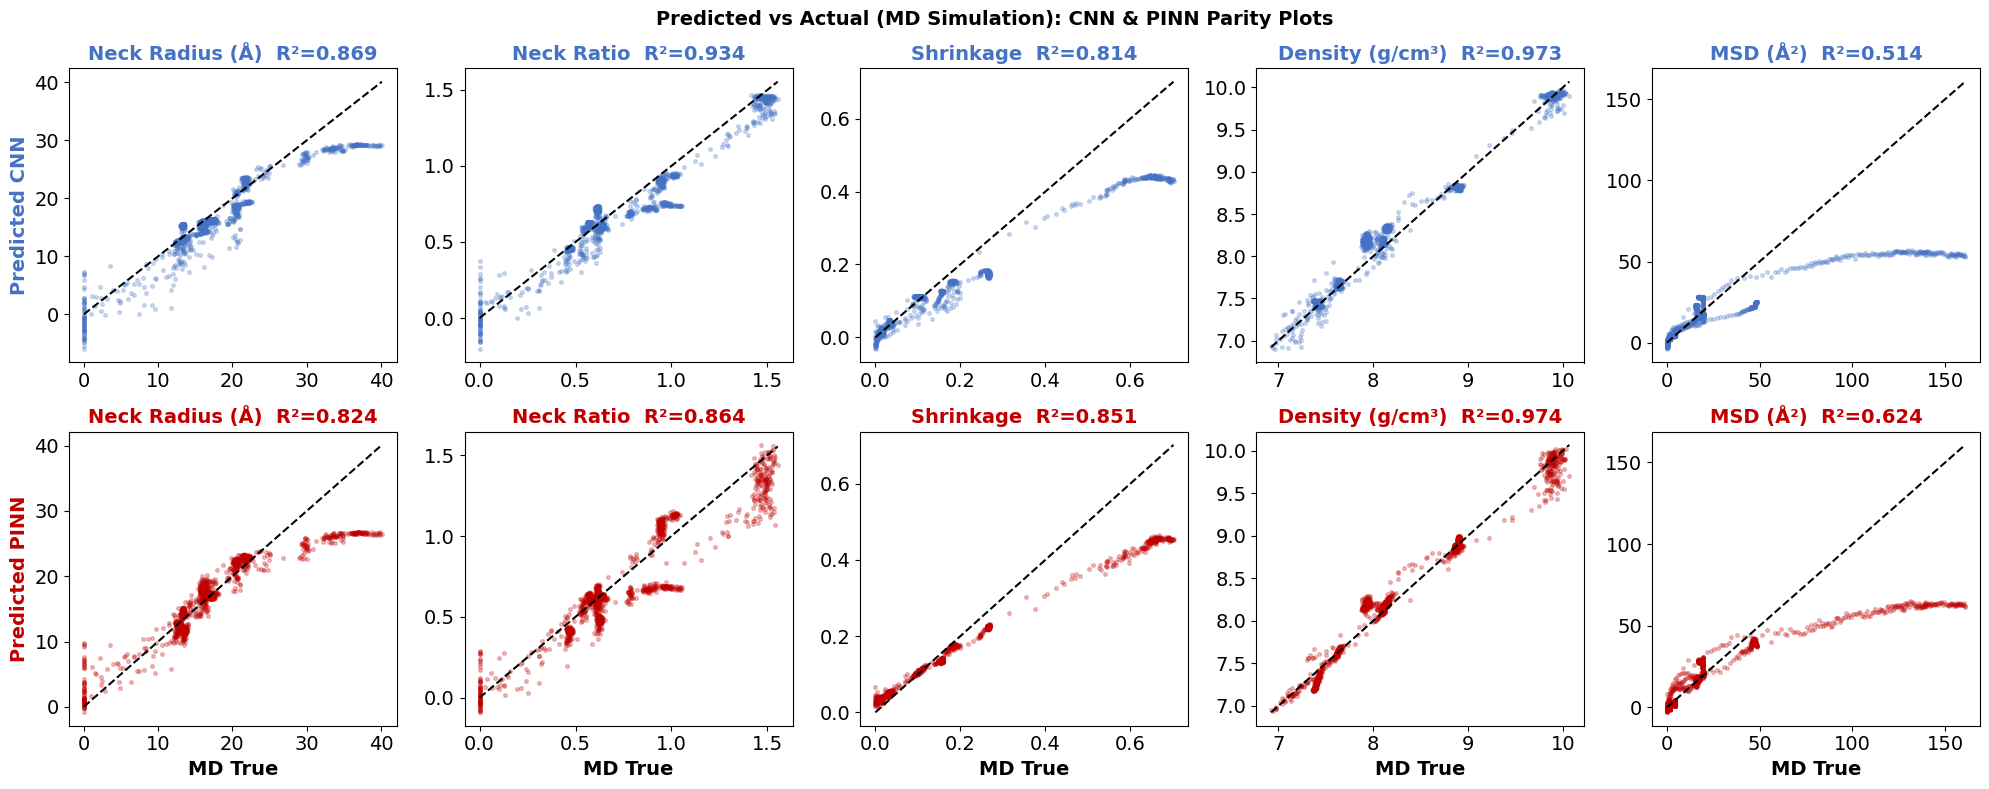

In [ ]:
# ============================================================
# 7.3 Parity Plots
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Predicted vs Actual (MD Simulation): CNN & PINN Parity Plots', fontsize=14, fontweight='bold')
ylabels = ['Neck Radius (Å)','Neck Ratio','Shrinkage','Density (g/cm³)','MSD (Å²)']

for col, (tgt_idx, yl) in enumerate(zip(range(5), ylabels)):
    for row, (mname, pred_all) in enumerate([('CNN',cnn_pred),('PINN',pinn_pred)]):
        ax = axes[row][col]
        true = Y_test_true[:,tgt_idx]
        pred = pred_all[:,tgt_idx]
        mn, mx = true.min(), true.max()
        ax.scatter(true, pred, alpha=0.25, s=7,
                   color='#4472C4' if row==0 else '#C00000')
        ax.plot([mn,mx],[mn,mx],'k--',lw=1.5,label='1:1')
        r2 = r2_score(true, pred)
        ax.set_title(f'{yl}  R²={r2:.3f}',color='#4472C4' if row==0 else '#C00000', fontsize=14, fontweight='bold') #\n
        axes[1][col].set_xlabel('MD True', fontsize=14, fontweight='bold')
        axes[row][0].set_ylabel(f'Predicted {mname}',color='#4472C4' if row==0 else '#C00000', fontsize=14, fontweight='bold')
        ax.tick_params(labelsize=14)
#axes[0, 0].set_ylabel('Predicted CNN', fontsize=14, fontweight='bold')
#axes[1, 0].set_ylabel('Predicted PINN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_parity.png', dpi=150, bbox_inches='tight')
plt.show()

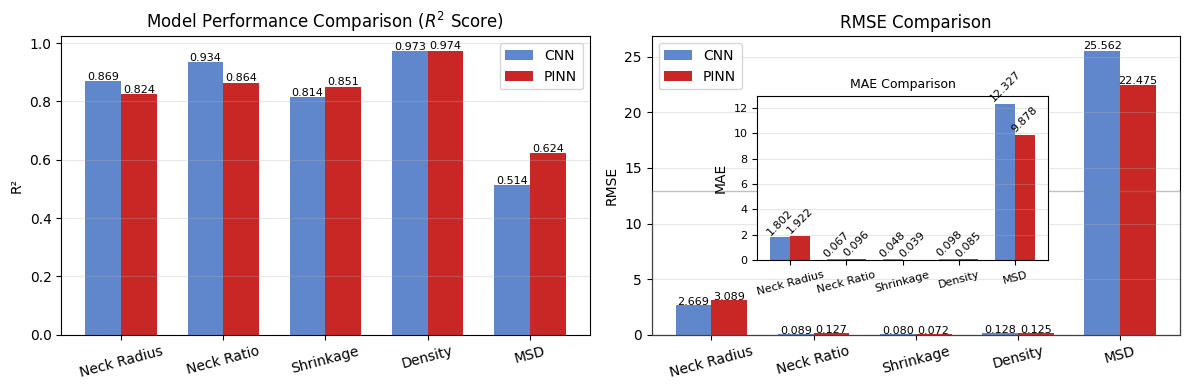

In [ ]:
# R² bar chart comparison with MAE inset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
tgt_labels = ['Neck Radius','Neck Ratio','Shrinkage','Density','MSD']
x = np.arange(len(TARGETS)); width = 0.35

# Create inset axes in the second plot
ax_inset = axes[1].inset_axes([0.20, 0.25, 0.55, 0.55])  # [x, y, width, height] in axes coordinates

for ax, metric_key in zip(axes, ['R²','RMSE']):
    cnn_v  = cnn_metrics[metric_key].values
    pinn_v = pinn_metrics[metric_key].values
    b1 = ax.bar(x-width/2, cnn_v,  width, label='CNN',  color='#4472C4', alpha=0.85)
    b2 = ax.bar(x+width/2, pinn_v, width, label='PINN', color='#C00000', alpha=0.85)

    # Add value labels on bars
    for b in list(b1)+list(b2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005*b.get_height(),
                f'{b.get_height():.3f}', ha='center', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(tgt_labels, rotation=15)
    ax.set_ylabel(metric_key); #ax.set_title(f'{metric_key} Comparison')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
axes[0].set_title('Model Performance Comparison ($R^2$ Score)')
axes[1].set_title('RMSE Comparison')

# Add MAE inset plot
cnn_mae = cnn_metrics['MAE'].values
pinn_mae = pinn_metrics['MAE'].values
ax_inset.bar(x-width/2, cnn_mae, width, label='CNN', color='#4472C4', alpha=0.85)
ax_inset.bar(x+width/2, pinn_mae, width, label='PINN', color='#C00000', alpha=0.85)

# Format inset plot
ax_inset.set_title('MAE Comparison', fontsize=9)
ax_inset.set_xticks(x)
ax_inset.set_xticklabels(tgt_labels, rotation=15, fontsize=8)
ax_inset.tick_params(axis='both', labelsize=8)
ax_inset.set_ylabel('MAE')
ax_inset.grid(axis='y', alpha=0.3)

# Add value labels to inset bars
for i, (cnn_val, pinn_val) in enumerate(zip(cnn_mae, pinn_mae)):
    ax_inset.text(i-width/2, cnn_val+0.005*cnn_val, f'{cnn_val:.3f}',
                  ha='center', fontsize=8, va='bottom',rotation=45,)
    ax_inset.text(i+width/2, pinn_val+0.005*pinn_val, f'{pinn_val:.3f}',
                  ha='center', fontsize=8, va='bottom',rotation=45,)

# Indicate inset location with rectangle
axes[1].indicate_inset_zoom(ax_inset, edgecolor="gray", alpha=0.5)

plt.tight_layout()
plt.savefig('fig9_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

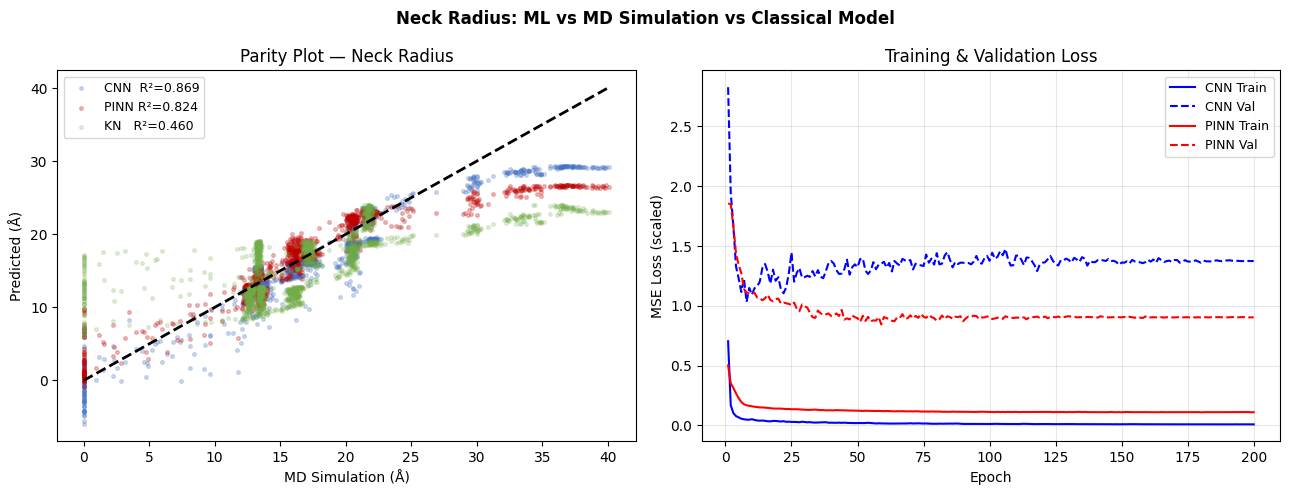

In [ ]:
# Classical vs ML comparison for neck radius
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Neck Radius: ML vs MD Simulation vs Classical Model', fontsize=12, fontweight='bold')

ax = axes[0]
true_nr = Y_test_true[:,0]
mn, mx = true_nr.min(), true_nr.max()
ax.scatter(true_nr, cnn_pred[:,0],  alpha=0.25, s=7,  c='#4472C4', label=f"CNN  R²={r2_score(true_nr,cnn_pred[:,0]):.3f}")
ax.scatter(true_nr, pinn_pred[:,0], alpha=0.25, s=7,  c='#C00000', label=f"PINN R²={r2_score(true_nr,pinn_pred[:,0]):.3f}")
ax.scatter(true_nr, classical_pred, alpha=0.2, s=7, c='#70AD47', label=f"KN   R²={classical_r2:.3f}")
ax.plot([mn,mx],[mn,mx],'k--',lw=2)
ax.set_xlabel('MD Simulation (Å)'); ax.set_ylabel('Predicted (Å)')
ax.set_title('Parity Plot — Neck Radius'); ax.legend(fontsize=9)

# Learning curves
ax2 = axes[1]
eps = np.arange(1, len(cnn_history['train'])+1)
ax2.plot(eps, cnn_history['train'],  'b-',  label='CNN Train', lw=1.5)
ax2.plot(eps, cnn_history['val'],    'b--', label='CNN Val', lw=1.5)
ax2.plot(eps, pinn_history['train'], 'r-',  label='PINN Train', lw=1.5)
ax2.plot(eps, pinn_history['val'],   'r--', label='PINN Val', lw=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss (scaled)')
ax2.set_title('Training & Validation Loss'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig10_classical_curves.png', dpi=150, bbox_inches='tight')
plt.show()

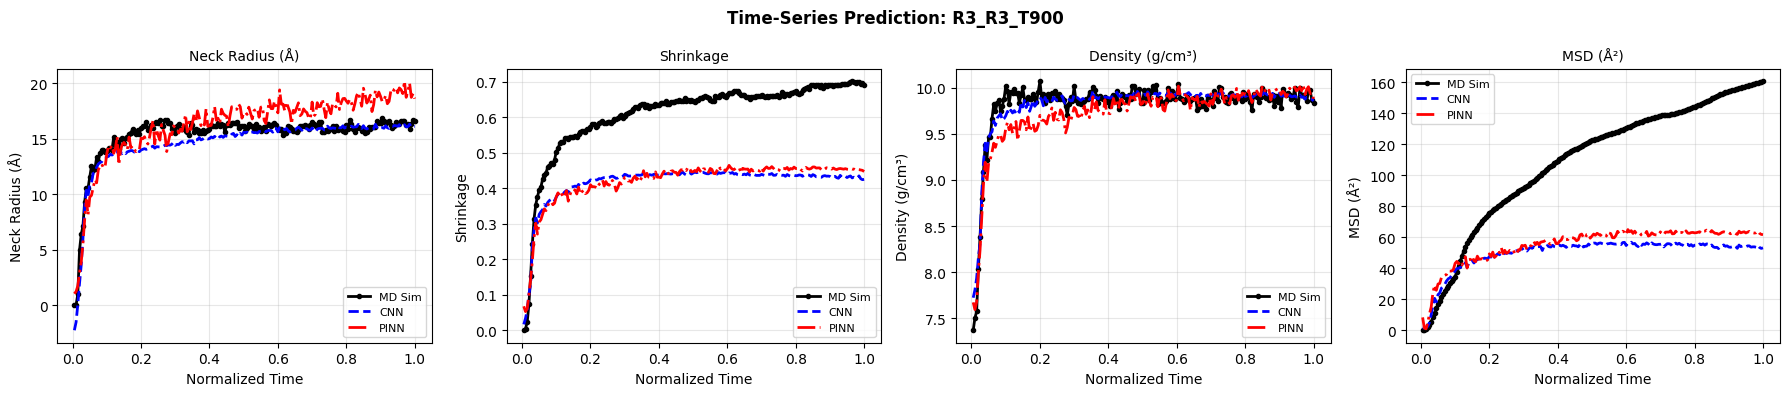

In [ ]:
# Time-series prediction for a single simulation
# Select one test simulation for visualization
test_sim_list = list(test_sims)
selected_sim = test_sim_list[6]
sim_mask = (df['sim_id'] == selected_sim).values & test_mask
if sim_mask.sum() > 5:
    t_plot = df.loc[sim_mask, 'time_norm']
    true = Y_test_true[sim_mask[test_mask], :]
    c_p = cnn_pred[sim_mask[test_mask], :]
    p_p = pinn_pred[sim_mask[test_mask], :]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Time-Series Prediction: {selected_sim}', fontsize=12, fontweight='bold')
    targets = [(0,'neck_radius','Neck Radius (Å)'),(2,'shrinkage','Shrinkage'),
               (3,'density','Density (g/cm³)'),(4,'msd','MSD (Å²)')]
    for ax, (tgt_i, tgt, yl) in enumerate(targets):
        axes[ax].plot(t_plot, true[:, tgt_i], 'ko-', ms=3, label='MD Sim', lw=2)
        axes[ax].plot(t_plot, c_p[:, tgt_i], 'b--', label='CNN', lw=2)
        axes[ax].plot(t_plot, p_p[:, tgt_i], 'r-.', label='PINN', lw=2)
        axes[ax].set_xlabel('Normalized Time'); axes[ax].set_ylabel(yl)
        axes[ax].set_title(yl, fontsize=10); axes[ax].legend(fontsize=8); axes[ax].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig11_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Select a different test simulation — this one has fewer than 5 test samples.')

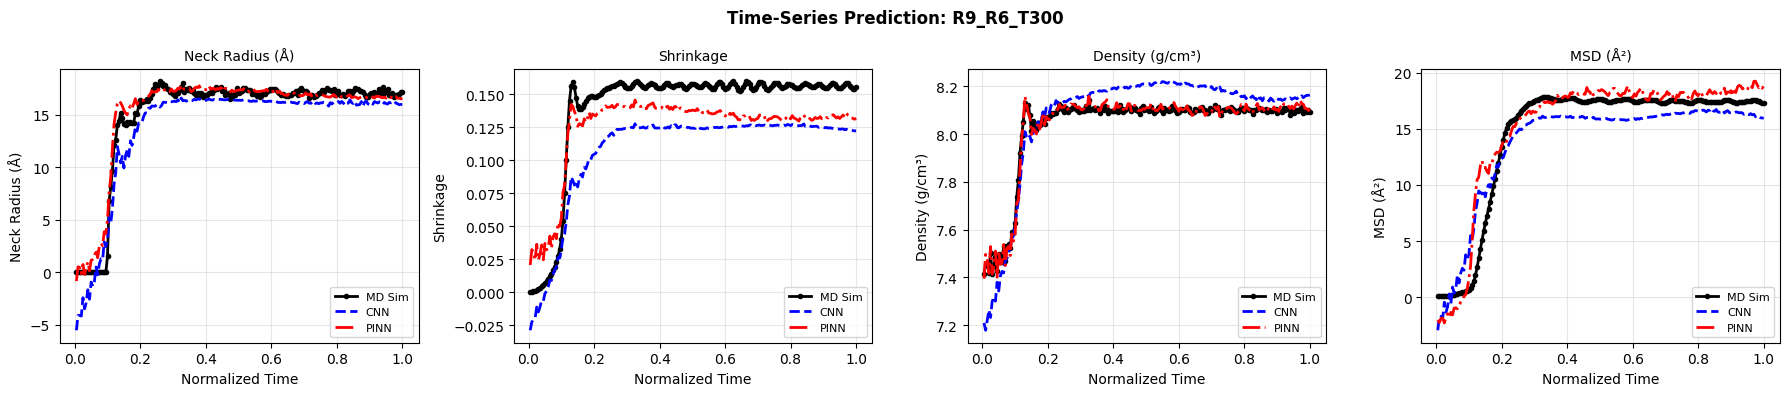

In [ ]:
# Time-series prediction for a single simulation
# Select one test simulation for visualization
test_sim_list = list(test_sims)
selected_sim = test_sim_list[0]
sim_mask = (df['sim_id'] == selected_sim).values & test_mask

if sim_mask.sum() > 5:
    sim_indices_in_test = sim_mask[test_mask]
    t_plot = df['time_norm'].values[sim_mask]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Time-Series Prediction: {selected_sim}', fontsize=12, fontweight='bold')
    for ax, (tgt_i, tgt, yl) in enumerate([
            (0,'neck_radius','Neck Radius (Å)'),(2,'shrinkage','Shrinkage'),
            (3,'density','Density (g/cm³)'),(4,'msd','MSD (Å²)')]):
        true = Y_test_true[sim_indices_in_test, tgt_i]
        c_p  = cnn_pred[sim_indices_in_test, tgt_i]
        p_p  = pinn_pred[sim_indices_in_test, tgt_i]
        axes[ax].plot(t_plot, true, 'ko-', ms=3, label='MD Sim', lw=2)
        axes[ax].plot(t_plot, c_p,  'b--', label='CNN', lw=2)
        axes[ax].plot(t_plot, p_p,  'r-.', label='PINN', lw=2)
        axes[ax].set_xlabel('Normalized Time'); axes[ax].set_ylabel(yl)
        axes[ax].set_title(yl, fontsize=10); axes[ax].legend(fontsize=8); axes[ax].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig12_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Select a different test simulation — this one has fewer than 5 test samples.')

## 8. Summary Metrics Table

In [ ]:
# Comprehensive summary
summary_rows = []
target_units = ['Å', '', '', 'g/cm³', 'Å²']
for i, (t, u) in enumerate(zip(TARGETS, target_units)):
    summary_rows.append({
        'Target': t, 'Unit': u,
        'CNN MAE': cnn_metrics.loc[t,'MAE'],
        'CNN RMSE': cnn_metrics.loc[t,'RMSE'],
        'CNN R²': cnn_metrics.loc[t,'R²'],
        'PINN MAE': pinn_metrics.loc[t,'MAE'],
        'PINN RMSE': pinn_metrics.loc[t,'RMSE'],
        'PINN R²': pinn_metrics.loc[t,'R²'],
    })

summary_df = pd.DataFrame(summary_rows)
print('\n=== FULL RESULTS SUMMARY ===')
display(summary_df.round(4))

print('\n=== Kuczynski Classical Model (Neck Radius only) ===')
print(f'MAE={classical_mae:.4f} Å | RMSE={classical_rmse:.4f} Å | R²={classical_r2:.4f}')


=== FULL RESULTS SUMMARY ===


,Target,Unit,CNN MAE,CNN RMSE,CNN R²,PINN MAE,PINN RMSE,PINN R²
0,neck_radius,Å,1.8020,2.6688,0.8689,1.9224,3.0893,0.8244
1,neck_ratio,,0.0667,0.0890,0.9335,0.0961,0.1273,0.8641
2,shrinkage,,0.0475,0.0804,0.8137,0.0388,0.0719,0.8512
3,density,g/cm³,0.0976,0.1277,0.9732,0.0851,0.1251,0.9742
4,msd,Å²,12.3272,25.5620,0.5140,9.8779,22.4746,0.6243



=== Kuczynski Classical Model (Neck Radius only) ===
MAE=3.8948 Å | RMSE=5.4169 Å | R²=0.4601


## 9. Save Models

In [ ]:
torch.save({
    'model_state': cnn.state_dict(),
    'scaler_X': scaler_X,
    'scaler_Y': scaler_Y,
    'features': FEATURES,
    'targets': TARGETS,
    'history': cnn_history
}, 'cnn_sintering.pt')

torch.save({
    'model_state': pinn.state_dict(),
    'scaler_X': scaler_X,
    'scaler_Y': scaler_Y,
    'features': FEATURES,
    'targets': TARGETS,
    'history': pinn_history
}, 'pinn_sintering.pt')

print('Models saved: cnn_sintering.pt, pinn_sintering.pt')

# -------------------------------------------------------
# Inference example
# -------------------------------------------------------
def predict_sintering(new_data_dict, model, scaler_X, scaler_Y, features):
    """Predict sintering properties from feature dict."""
    x = np.array([[new_data_dict[f] for f in features]], dtype=np.float32)
    x_sc = scaler_X.transform(x)
    x_t  = torch.tensor(x_sc, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        model.eval()
        pred_sc = model(x_t).cpu().numpy()
    pred = scaler_Y.inverse_transform(pred_sc)
    return dict(zip(TARGETS, pred.ravel()))

# Example prediction
sample = {f: float(X_all[100, FEATURES.index(f)]) for f in FEATURES}
predictions = predict_sintering(sample, cnn, scaler_X, scaler_Y, FEATURES)
predictionp = predict_sintering(sample, pinn, scaler_X, scaler_Y, FEATURES)
print('\nSample Prediction (CNN):')
for k, v in predictions.items(): print(f'  {k}: {v:.4f}')
print('\nSample Prediction (PINN):')
for k, v in predictionp.items(): print(f'  {k}: {v:.4f}')

Models saved: cnn_sintering.pt, pinn_sintering.pt

Sample Prediction (CNN):
  neck_radius: 17.9303
  neck_ratio: 0.5395
  shrinkage: 0.1230
  density: 7.7142
  msd: 19.4101

Sample Prediction (PINN):
  neck_radius: 18.3752
  neck_ratio: 0.5631
  shrinkage: 0.1207
  density: 7.7008
  msd: 19.6548
